# 03 — Logistic regression and classification

Regression predicts a number. Classification predicts a category. The move from
one to the other requires two changes, and the second is more subtle than it looks.

1. **Squash the output** into $(0, 1)$ so it can be read as a probability — the sigmoid.
2. **Change the loss.** MSE on probabilities is a bad idea, and we will see exactly why.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(42)

## The sigmoid

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

It maps all of $\mathbb{R}$ into $(0,1)$, is monotonic, and has a derivative with
a famously convenient form:

$$\sigma'(z) = \sigma(z)\,(1 - \sigma(z))$$

Note that derivative is at most 0.25, and approaches 0 at both extremes. That
**saturation** is the root cause of vanishing gradients in deep sigmoid networks —
we will meet it again in chapter 04.

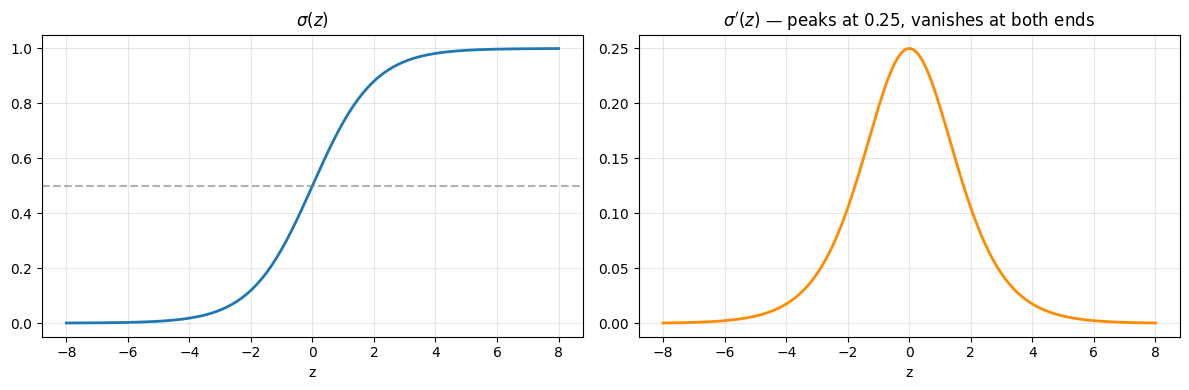

sigmoid(-1000) = 0.0 (no overflow)


In [2]:
from mlscratch.activations import sigmoid, sigmoid_prime_from_output

z = np.linspace(-8, 8, 200)
a = sigmoid(z)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(z, a, lw=2); axes[0].axhline(0.5, ls="--", c="gray", alpha=0.6)
axes[0].set_title(r"$\sigma(z)$"); axes[0].set_xlabel("z"); axes[0].grid(alpha=0.3)

axes[1].plot(z, sigmoid_prime_from_output(a), lw=2, c="darkorange")
axes[1].set_title(r"$\sigma'(z)$ — peaks at 0.25, vanishes at both ends")
axes[1].set_xlabel("z"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# The naive formula overflows; ours does not.
print("sigmoid(-1000) =", sigmoid(np.array([-1000.0]))[0], "(no overflow)")

## Why not mean squared error?

Two reasons, and the second is the one that matters.

**Reason 1: MSE on a sigmoid output is non-convex in the weights.** Local minima
become possible. Cross entropy is convex here.

**Reason 2: the gradients vanish exactly when you need them most.** If the model
predicts 0.99 and the truth is 0, MSE's gradient carries a $\sigma'(z)$ factor,
which is nearly zero out there. The model is confidently wrong and barely learns.
Cross entropy's gradient grows without bound as confidence in the wrong answer grows.

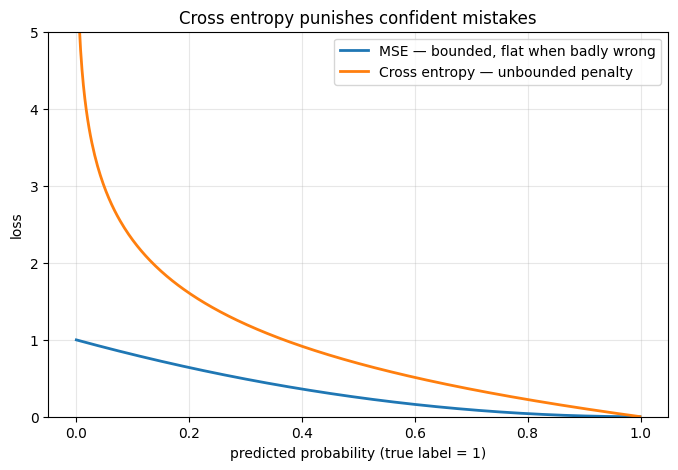

In [3]:
p = np.linspace(0.001, 0.999, 400)
y_true = 1.0

mse_loss = (p - y_true) ** 2
bce_loss = -np.log(p)

plt.figure(figsize=(8, 5))
plt.plot(p, mse_loss, lw=2, label="MSE — bounded, flat when badly wrong")
plt.plot(p, bce_loss, lw=2, label="Cross entropy — unbounded penalty")
plt.xlabel("predicted probability (true label = 1)"); plt.ylabel("loss")
plt.title("Cross entropy punishes confident mistakes"); plt.ylim(0, 5)
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Binary cross entropy

$$L = -\frac{1}{n}\sum_i \big[ y_i \log p_i + (1-y_i)\log(1-p_i) \big]$$

Only one term is ever active per sample: $y=1$ keeps $-\log p$, $y=0$ keeps $-\log(1-p)$.

**The gradient.** Work through the chain rule and something remarkable happens —
the $\sigma'(z)$ factor cancels against the denominator of the cross-entropy
derivative, leaving:

$$\frac{\partial L}{\partial \theta} = \frac{1}{n} X^\top (p - y)$$

Identical in form to linear regression. That cancellation is not a coincidence;
it is why this pairing of loss and activation is standard.

In [4]:
from mlscratch.losses import binary_cross_entropy

def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def fit_logistic(X, y, lr=0.5, n_iters=1000):
    Xb = add_bias(X)
    n, d = Xb.shape
    theta = np.zeros(d)
    history = []
    for _ in range(n_iters):
        p = sigmoid(Xb @ theta)
        history.append(binary_cross_entropy(y, p))
        grad = Xb.T @ (p - y) / n        # the cancellation above
        theta -= lr * grad
    return theta, history

### Verify the gradient before trusting the model

An analytic gradient that is subtly wrong will still produce a loss curve that
goes down. The only way to be sure is to compare against finite differences.

In [5]:
from mlscratch.utils import numerical_gradient, relative_error

X_check = rng.normal(size=(20, 3))
y_check = rng.integers(0, 2, 20).astype(float)
Xb_check = add_bias(X_check)
theta_check = rng.normal(size=4) * 0.5

analytic = Xb_check.T @ (sigmoid(Xb_check @ theta_check) - y_check) / len(y_check)
numeric = numerical_gradient(
    lambda t: binary_cross_entropy(y_check, sigmoid(Xb_check @ t)), theta_check.copy()
)

print("analytic:", analytic)
print("numeric: ", numeric)
print("relative error:", relative_error(analytic, numeric))
print("PASS" if relative_error(analytic, numeric) < 1e-6 else "FAIL")

analytic: [-0.208 -0.13  -0.037  0.096]
numeric:  [-0.208 -0.13  -0.037  0.096]
relative error: 1.1776911611508988e-10
PASS


## Train on separable data

In [6]:
n = 400
X = rng.normal(size=(n, 2))
y = (X[:, 0] + X[:, 1] > 0.3).astype(float)
X += rng.normal(0, 0.25, X.shape)          # blur the boundary

theta, history = fit_logistic(X, y, lr=0.5, n_iters=1500)

from mlscratch.metrics import accuracy, precision_recall_f1, confusion_matrix
preds = (sigmoid(add_bias(X) @ theta) >= 0.5).astype(int)

print("theta:", theta)
print(f"accuracy: {accuracy(y, preds):.3f}")
prec, rec, f1 = precision_recall_f1(y, preds)
print(f"precision {prec:.3f}  recall {rec:.3f}  f1 {f1:.3f}")
print("\nconfusion matrix (rows = true, cols = predicted):")
print(confusion_matrix(y.astype(int), preds))

theta: [-1.667  4.496  4.651]
accuracy: 0.920
precision 0.899  recall 0.899  f1 0.899

confusion matrix (rows = true, cols = predicted):
[[226  16]
 [ 16 142]]


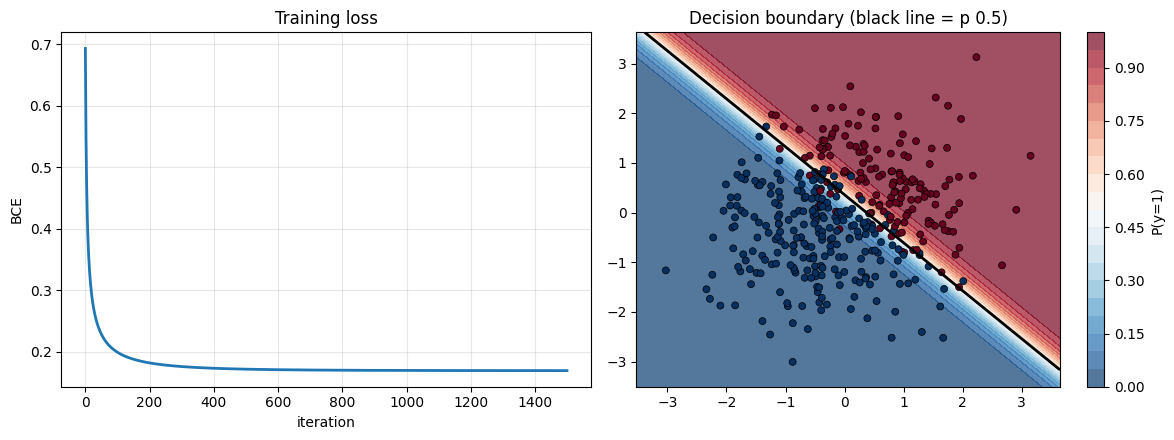

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history, lw=2)
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("BCE")
axes[0].set_title("Training loss"); axes[0].grid(alpha=0.3)

# Decision boundary: fill the plane with predicted probability.
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - .5, X[:, 0].max() + .5, 200),
                     np.linspace(X[:, 1].min() - .5, X[:, 1].max() + .5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = sigmoid(add_bias(grid) @ theta).reshape(xx.shape)

cs = axes[1].contourf(xx, yy, zz, levels=20, cmap="RdBu_r", alpha=0.7)
axes[1].contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=2)
axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu_r", edgecolors="k", s=25, linewidths=0.5)
axes[1].set_title("Decision boundary (black line = p 0.5)")
plt.colorbar(cs, ax=axes[1], label="P(y=1)")
plt.tight_layout(); plt.show()

## The threshold is a choice, not a constant

0.5 is a default, not a law. Lowering it catches more positives at the cost of
more false alarms. In fraud detection or medical screening, missing a positive
costs far more than a false alarm, and the threshold should reflect that.

In [8]:
probs = sigmoid(add_bias(X) @ theta)
print(f"{'threshold':>10} {'accuracy':>9} {'precision':>10} {'recall':>8}")
print("-" * 40)
for t in [0.1, 0.3, 0.5, 0.7, 0.9]:
    pr = (probs >= t).astype(int)
    prec, rec, _ = precision_recall_f1(y, pr)
    print(f"{t:>10.1f} {accuracy(y, pr):>9.3f} {prec:>10.3f} {rec:>8.3f}")

 threshold  accuracy  precision   recall
----------------------------------------
       0.1     0.850      0.736    0.968
       0.3     0.915      0.856    0.943
       0.5     0.920      0.899    0.899
       0.7     0.922      0.964    0.835
       0.9     0.890      0.991    0.728


## What logistic regression cannot do

The decision boundary is a straight line. Always. XOR — where the classes sit on
opposite diagonal corners — has no straight line that separates it.

This is not a tuning problem. No learning rate, no number of iterations fixes it.
It is a limitation of the model class, and it is precisely why we need hidden layers.

In [9]:
X_xor = np.array([[0.0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0.0, 1, 1, 0])

theta_xor, hist_xor = fit_logistic(X_xor, y_xor, lr=0.5, n_iters=5000)
p_xor = sigmoid(add_bias(X_xor) @ theta_xor)

print("XOR predictions:", p_xor.round(3))
print("true labels:    ", y_xor)
print(f"\nfinal loss: {hist_xor[-1]:.4f}  (0.693 = ln 2 = pure guessing)")
print("The model has learned nothing. It cannot.")

XOR predictions: [0.5 0.5 0.5 0.5]
true labels:     [0. 1. 1. 0.]

final loss: 0.6931  (0.693 = ln 2 = pure guessing)
The model has learned nothing. It cannot.


## Exercises

1. **Multiclass.** Replace sigmoid with softmax and BCE with categorical cross
   entropy. Show that softmax with 2 classes reduces to sigmoid.
2. **L2 regularisation.** Add $\lambda\|\theta\|^2$. Why must the intercept be excluded?
3. **ROC curve.** Sweep the threshold from 0 to 1, plot TPR against FPR, compute AUC.
4. **Perfect separation.** Make the classes fully separable and train for a long
   time. Watch the weights grow without bound — and explain why regularisation fixes it.

---

**Next:** [04 — Neural networks and backpropagation](04_neural_network_backprop.ipynb)